# CSE425 PROJECT 

In [11]:
import torch

if torch.cuda.device_count() > 1:
    print(f"✅ {torch.cuda.device_count()} GPUs available. Using DataParallel.")
    use_multi_gpu = True
else:
    print(f"Only {torch.cuda.device_count()} GPU detected. Running on single GPU.")
    use_multi_gpu = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def wrap_model(model):
    if use_multi_gpu and torch.cuda.device_count() > 1:
        return nn.DataParallel(model)
    return model

print(f"Final DEVICE: {DEVICE} | Multi-GPU: {use_multi_gpu}")

✅ 2 GPUs available. Using DataParallel.
Final DEVICE: cuda | Multi-GPU: True


In [12]:
!pip install pretty_midi miditok -q

In [13]:
import os, glob, time, random
import numpy as np
import pandas as pd
import pretty_midi
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from math import pi

#CONFIG 
TEST_MODE = False  
MAX_FILES = 30 if TEST_MODE else None

DATA_ROOT = "/kaggle/input/datasets/pretomareefinpranto/cse425-all-year-prets/all_year_files"
CSV_PATH = os.path.join(DATA_ROOT, "maestro-v3.0.0.csv")
MIDI_DIR = DATA_ROOT

WINDOW_LEN = 128
FS = 16
BATCH_SIZE = 32 if TEST_MODE else 64
EPOCHS_AE = 30 if TEST_MODE else 40
EPOCHS_VAE = 30 if TEST_MODE else 40
EPOCHS_TR = 20 if TEST_MODE else 30

LATENT_DIM = 64
HIDDEN_SIZE = 256

os.makedirs("outputs/generated_midis", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)  


print(f"Device: {DEVICE} | TEST_MODE: {TEST_MODE}")

Device: cuda | TEST_MODE: False


In [14]:
df = pd.read_csv(CSV_PATH)
df['basename'] = df['midi_filename'].apply(os.path.basename)
actual_files = [f for f in os.listdir(MIDI_DIR) if f.endswith('.midi')]
df = df[df['basename'].isin(actual_files)].copy()
df['midi_path'] = df['basename'].apply(lambda x: os.path.join(MIDI_DIR, x))

train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'validation'].copy()

if TEST_MODE and MAX_FILES:
    train_df = train_df.head(MAX_FILES)
    val_df = val_df.head(max(5, MAX_FILES//4))

print(f"Train files: {len(train_df)} | Val files: {len(val_df)}")

Train files: 962 | Val files: 137


**PIANO-ROLL PREPROCESSING**

In [15]:
def midi_to_windows(midi_path):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        pr = midi.get_piano_roll(fs=FS)[21:109, :]
        pr = (pr > 0).astype(np.float32).T
        windows = []
        for i in range(0, len(pr) - WINDOW_LEN + 1, WINDOW_LEN):
            w = pr[i:i+WINDOW_LEN]
            if np.mean(w) >= 0.02:
                windows.append(w)
        return windows
    except:
        return []

print("Building piano-roll windows...")
train_windows, val_windows = [], []
for p in tqdm(train_df['midi_path'].tolist(), desc="Training"):
    train_windows.extend(midi_to_windows(p))
for p in tqdm(val_df['midi_path'].tolist(), desc="Validation"):
    val_windows.extend(midi_to_windows(p))

# Fallback for empty data
if not train_windows:
    train_windows = [np.random.rand(WINDOW_LEN, 88).astype(np.float32) for _ in range(100)]
if not val_windows and train_windows:
    val_windows = train_windows[:100]

train_data = np.stack(train_windows)
val_data = np.stack(val_windows)
np.save("data/processed/train_pianoroll.npy", train_data)
np.save("data/processed/val_pianoroll.npy", val_data)
print(f"Train: {train_data.shape}, Val: {val_data.shape}")

Building piano-roll windows...


Validation: 100%|██████████| 137/137 [00:29<00:00,  4.64it/s]


Train: (62689, 128, 88), Val: (7876, 128, 88)


**MODEL DEFINITIONS**

In [16]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, inputs, targets):
        BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE)
        return (self.alpha * (1-pt)**self.gamma * BCE).mean()

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=88, hidden_size=256, latent_dim=64, num_layers=2):
        super().__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc_z = nn.Linear(hidden_size, latent_dim)
        self.decoder_fc = nn.Linear(latent_dim, hidden_size)
        self.decoder = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z = self.fc_z(h[-1])
        z_rep = self.decoder_fc(z.unsqueeze(1).repeat(1, x.size(1), 1))
        dec_out, _ = self.decoder(z_rep)
        return self.output_layer(dec_out), z

    def generate(self, z, seq_len=128, threshold=0.35):
        self.eval()
        with torch.no_grad():
            z_rep = self.decoder_fc(z.unsqueeze(1).repeat(1, seq_len, 1))
            dec_out, _ = self.decoder(z_rep)
            return (torch.sigmoid(self.output_layer(dec_out)) > threshold).float()
            
class VAE(LSTMAutoencoder):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
        self.fc_logvar = nn.Linear(256, LATENT_DIM)  
    
    def encode(self, x):
        _, (h, _) = self.encoder(x)
        h = h[-1]
        return self.fc_z(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        z_rep = self.decoder_fc(z.unsqueeze(1).repeat(1, x.size(1), 1))
        dec_out, _ = self.decoder(z_rep)
        return self.output_layer(dec_out), mu, logvar

# TASK1 : LSTM AUTOENCODER

In [17]:
class PianoRollDataset(Dataset):
    def __init__(self, npy_path): 
        self.data = np.load(npy_path)
    def __len__(self): 
        return len(self.data)
    def __getitem__(self, i): 
        return torch.tensor(self.data[i], dtype=torch.float32)

train_ds = PianoRollDataset("data/processed/train_pianoroll.npy")
val_ds = PianoRollDataset("data/processed/val_pianoroll.npy")
loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

ae_model = wrap_model(LSTMAutoencoder().to(DEVICE))
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
criterion = FocalLoss()
ae_train_losses, ae_val_losses = [], []
ae_train_losses, ae_val_losses = [], []

print("\n" + "="*50)
print("TASK 1: Training LSTM Autoencoder")
print("="*50)

for epoch in range(EPOCHS_AE):
    ae_model.train()
    epoch_loss = 0.0
    for batch in tqdm(loader, desc=f"Epoch {epoch+1}", leave=False):
        batch = batch.to(DEVICE)
        recon, _ = ae_model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ae_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item() * batch.size(0)
    train_loss = epoch_loss / len(train_ds)
    
    ae_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            recon, _ = ae_model(batch)
            val_loss += criterion(recon, batch).item() * batch.size(0)
    val_loss /= len(val_ds)
    
    ae_train_losses.append(train_loss)
    ae_val_losses.append(val_loss)
    print(f"Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

torch.save(ae_model.state_dict(), "outputs/models/ae_final.pth")

#loss curve
plt.figure(figsize=(8,4))
plt.plot(ae_train_losses, label="Train", color="#4C72B0")
plt.plot(ae_val_losses, label="Validation", color="#DD8452", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Focal Loss")
plt.title("Task 1 — LSTM Autoencoder Loss")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/plots/task1_ae_loss.png", dpi=150)
plt.close()
print("Task 1 is complete – loss curve saved to outputs/plots/task1_ae_loss.png")


TASK 1: Training LSTM Autoencoder


Epoch   1 | Train: 0.0139 | Val: 0.0133


Epoch   2 | Train: 0.0137 | Val: 0.0134


Epoch   3 | Train: 0.0137 | Val: 0.0133


Epoch   4 | Train: 0.0137 | Val: 0.0133


...

Epoch  36 | Train: 0.0137 | Val: 0.0133


Epoch  37 | Train: 0.0137 | Val: 0.0133


Epoch  38 | Train: 0.0137 | Val: 0.0133


Epoch  39 | Train: 0.0137 | Val: 0.0133


Epoch  40 | Train: 0.0137 | Val: 0.0133
Task 1 is complete – loss curve saved to outputs/plots/task1_ae_loss.png


# TASK 2: VAE

In [18]:
vae_model = wrap_model(VAE().to(DEVICE))
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

vae_recon_losses, vae_kl_losses, vae_val_losses = [], [], []

print("\n" + "="*50)
print("TASK 2: Training VAE")
print("="*50)

for epoch in range(EPOCHS_VAE):
    beta = min(1.0, epoch / max(EPOCHS_VAE * 0.3, 1))
    vae_model.train()
    epoch_recon, epoch_kl = 0.0, 0.0
    for batch in tqdm(loader, desc=f"Epoch {epoch+1}", leave=False):
        batch = batch.to(DEVICE)
        recon, mu, logvar = vae_model(batch)
        recon_loss = criterion(recon, batch)
        kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kld
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae_model.parameters(), 1.0)
        optimizer.step()
        epoch_recon += recon_loss.item() * batch.size(0)
        epoch_kl += kld.item() * batch.size(0)
    
    train_recon = epoch_recon / len(train_ds)
    train_kl = epoch_kl / len(train_ds)
    
    vae_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            recon, mu, logvar = vae_model(batch)
            recon_loss = criterion(recon, batch)
            kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            val_loss += (recon_loss + beta * kld).item() * batch.size(0)
    val_loss /= len(val_ds)
    
    vae_recon_losses.append(train_recon)
    vae_kl_losses.append(train_kl)
    vae_val_losses.append(val_loss)
    print(f"Epoch {epoch+1:3d} | β={beta:.2f} | Recon={train_recon:.4f} | KL={train_kl:.4f} | Val={val_loss:.4f}")

torch.save(vae_model.state_dict(), "outputs/models/vae_final.pth")

#Save loss curves (reconstruction + KL)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(vae_recon_losses, label="Train Recon", color="#4C72B0")
ax1.plot(vae_val_losses, label="Validation Total", color="#DD8452", linestyle="--")
ax1.set_title("VAE Reconstruction Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax2.plot(vae_kl_losses, label="Train KL", color="#55A868")
ax2.set_title("VAE KL Divergence")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.suptitle("Task 2 — VAE Training Curves")
plt.tight_layout()
plt.savefig("outputs/plots/task2_vae_loss.png", dpi=150)
plt.close()
print("Task 2 is complete – loss curves saved to outputs/plots/task2_vae_loss.png")


TASK 2: Training VAE


Epoch   1 | β=0.00 | Recon=0.0139 | KL=5.0786 | Val=0.0133


Epoch   2 | β=0.08 | Recon=0.0138 | KL=0.0077 | Val=0.0134


Epoch   3 | β=0.17 | Recon=0.0137 | KL=0.0000 | Val=0.0133


Epoch   4 | β=0.25 | Recon=0.0137 | KL=0.0000 | Val=0.0133


...

Epoch  36 | β=1.00 | Recon=0.0137 | KL=0.0000 | Val=0.0133


Epoch  37 | β=1.00 | Recon=0.0137 | KL=0.0000 | Val=0.0133


Epoch  38 | β=1.00 | Recon=0.0137 | KL=0.0000 | Val=0.0133


Epoch  39 | β=1.00 | Recon=0.0137 | KL=0.0000 | Val=0.0134


Epoch  40 | β=1.00 | Recon=0.0137 | KL=0.0000 | Val=0.0133
Task 2 is complete – loss curves saved to outputs/plots/task2_vae_loss.png


In [19]:
#VAE LATENT INTERPOLATION (Task 2 deliverable)
def vae_interpolation(model, file1, file2, num_steps=8, window_len=WINDOW_LEN):
    model.eval()
    if isinstance(model, nn.DataParallel):
        model = model.module              
    def midi_to_first_window(path):
        pr = midi_to_windows(path)
        if not pr:
            return np.random.rand(window_len, 88).astype(np.float32) #randomised noise
        return pr[0]
    pr1 = midi_to_first_window(file1)
    pr2 = midi_to_first_window(file2)
    x1 = torch.tensor(pr1, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    x2 = torch.tensor(pr2, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    mu1, _ = model.encode(x1)
    mu2, _ = model.encode(x2)
    alphas = np.linspace(0, 1, num_steps)
    interp_midis = []
    for i, a in enumerate(alphas):
        z = (1 - a) * mu1 + a * mu2
        with torch.no_grad():
            z_rep = model.decoder_fc(z.unsqueeze(1).repeat(1, window_len, 1))
            dec_out, _ = model.decoder(z_rep)
            probs = torch.sigmoid(model.output_layer(dec_out))
            binary = (probs > 0.28).float().cpu().numpy()[0]
        pm = pretty_midi.PrettyMIDI()
        piano = pretty_midi.Instrument(program=0)
        for t in range(window_len):
            for p in range(88):
                if binary[t, p] == 1:
                    duration = random.uniform(0.18, 2.5)
                    piano.notes.append(pretty_midi.Note(
                        velocity=random.randint(60, 100),
                        pitch=p + 21,
                        start=t / FS,
                        end=t / FS + duration
                    ))
        pm.instruments.append(piano)
        out_path = f"outputs/generated_midis/vae_interp_{i:02d}.mid"
        pm.write(out_path)
        interp_midis.append(out_path)
    print(f"Saved {len(interp_midis)} interpolation MIDI files (alpha from 0 to 1)")
    return interp_midis
#checker for interp
if len(val_df) >= 2:
    interp_files = vae_interpolation(vae_model, val_df.iloc[0]['midi_path'], val_df.iloc[1]['midi_path'])
else:
    interp_files = vae_interpolation(vae_model, train_df.iloc[0]['midi_path'], train_df.iloc[1]['midi_path'])

Saved 8 interpolation MIDI files (alpha from 0 to 1)


# TASK 3: TRANSFORMER (REMI)

In [20]:
# ========================= TASK 3: TRANSFORMER (REMI) =========================
print("\n" + "="*50)
print("TASK 3: Setting up Transformer")
print("="*50)

try:
    from miditok import REMI, TokenizerConfig
    
    config = TokenizerConfig(
        pitch_range=(21, 109),
        beat_res={(0, 4): 8, (4, 12): 4},
        num_velocities=32,
        use_chords=False,
        use_rests=True,
    )
    
    tokenizer = REMI(config)
    midi_paths = [Path(p) for p in train_df['midi_path'].tolist()[:100 if TEST_MODE else 400]]
    
    if midi_paths:
        print(f"Training tokenizer on {len(midi_paths)} files...")
        tokenizer.train(vocab_size=8000, files_paths=midi_paths)
        tokenizer.save("data/processed/remi_tokenizer.json")
        print(f" Vocabulary size: {len(tokenizer)}")
        
        class TokenDataset(Dataset):
            def __init__(self, midi_files, tokenizer, max_len=256):
                self.sequences = []
                for path in tqdm(midi_files, desc="Tokenizing", leave=False):
                    try:
                        result = tokenizer(Path(path))
                        if result and result[0]:
                            token_ids = result[0].ids
                            if len(token_ids) >= 50:
                                for i in range(0, len(token_ids) - max_len + 1, max_len//2):
                                    chunk = token_ids[i:i+max_len]
                                    if len(chunk) >= 50:
                                        self.sequences.append(torch.tensor(chunk, dtype=torch.long))
                    except:
                        continue
                print(f"Created {len(self.sequences)} sequences")
            
            def __len__(self):
                return len(self.sequences)
            def __getitem__(self, idx):
                return self.sequences[idx]
        
        train_token_ds = TokenDataset(train_df['midi_path'].tolist()[:100], tokenizer)
        val_token_ds = TokenDataset(val_df['midi_path'].tolist()[:20], tokenizer)
        print(f"Train seqs: {len(train_token_ds)} | Val seqs: {len(val_token_ds)}")
        assert len(train_token_ds) > 0, "No training sequences – cannot train Transformer"
        if len(train_token_ds) > 0:
            def collate_fn(batch):
                return torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0)
            
            class MusicTransformer(nn.Module):
                def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=4, max_len=1024):
                    super().__init__()
                    self.embedding = nn.Embedding(vocab_size, d_model)
                    self.pos_enc = nn.Parameter(torch.zeros(1, max_len, d_model))
                    # Use TransformerEncoder with causal mask (no cross-attention)
                    encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, batch_first=True, dropout=0.2)
                    self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
                    self.fc_out = nn.Linear(d_model, vocab_size)
            
                def forward(self, x):
                    seq_len = x.size(1)
                    embed = self.embedding(x) + self.pos_enc[:, :seq_len, :]
                    # Causal mask: upper triangular (True = masked out)
                    mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
                    out = self.transformer(embed, mask=mask)
                    return self.fc_out(out)
            train_loader = DataLoader(train_token_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
            val_loader = DataLoader(val_token_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
            
            trans_model = wrap_model(MusicTransformer(len(tokenizer)).to(DEVICE))
            optimizer = torch.optim.Adam(trans_model.parameters(), lr=3e-4)
            criterion = nn.CrossEntropyLoss(ignore_index=0)
            
            trans_train_ppls, trans_val_ppls = [], []
            
            print("\nTraining Transformer...")
            for epoch in range(EPOCHS_TR):
                trans_model.train()
                total_loss = 0
                for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
                    batch = batch.to(DEVICE)
                    inp, tgt = batch[:, :-1], batch[:, 1:]
                    logits = trans_model(inp)
                    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1))
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(trans_model.parameters(), 1.0)
                    optimizer.step()
                    total_loss += loss.item()
                
                train_ppl = np.exp(min(total_loss / len(train_loader), 10))
                
                trans_model.eval()
                val_loss = 0
                with torch.no_grad():
                    for batch in val_loader:
                        batch = batch.to(DEVICE)
                        inp, tgt = batch[:, :-1], batch[:, 1:]
                        logits = trans_model(inp)
                        val_loss += criterion(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1)).item()
                val_ppl = np.exp(min(val_loss / max(len(val_loader), 1), 10))
                
                trans_train_ppls.append(train_ppl)
                trans_val_ppls.append(val_ppl)
                print(f"Epoch {epoch+1:3d} | Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f}")
            
            torch.save(trans_model.state_dict(), "outputs/models/transformer_final.pth")
            
            plt.figure(figsize=(8, 4))
            plt.plot(trans_train_ppls, label="Train", color="#4C72B0")
            plt.plot(trans_val_ppls, label="Val", color="#DD8452", linestyle="--")
            plt.xlabel("Epoch")
            plt.ylabel("Perplexity")
            plt.title("Task 3 — Transformer Perplexity")
            plt.legend()
            plt.tight_layout()
            plt.savefig("outputs/plots/task3_transformer_ppl.png", dpi=150)
            plt.close()
            print("Task 3 complete")
        else:
            print( "Insufficient training data, skipping transformer")
            trans_model = None
    else:
        trans_model = None
except ImportError:
    print("miditok not available, skipping transformer")
    trans_model = None


TASK 3: Setting up Transformer
Training tokenizer on 400 files...



 Vocabulary size: 8000


Created 6221 sequences


Created 1289 sequences
Train seqs: 6221 | Val seqs: 1289

Training Transformer...


Epoch   1 | Train PPL: 3103.02 | Val PPL: 2882.45


Epoch   2 | Train PPL: 2288.74 | Val PPL: 1978.62


...

Epoch  26 | Train PPL: 106.29 | Val PPL: 407.91


Epoch  27 | Train PPL: 101.03 | Val PPL: 409.93


Epoch  28 | Train PPL: 96.42 | Val PPL: 420.94


Epoch  29 | Train PPL: 92.26 | Val PPL: 432.62


Epoch  30 | Train PPL: 88.65 | Val PPL: 441.35
Task 3 complete


In [21]:
def generate_from_model(model, model_type="ae", num_samples=5, temperature=0.92):
    if isinstance(model, nn.DataParallel):
        model = model.module
    os.makedirs("outputs/generated_midis", exist_ok=True)
    files = []
    for i in range(num_samples):
        if model_type in ["ae", "vae"]:
            z = torch.randn(1, LATENT_DIM).to(DEVICE)
            with torch.no_grad():
                binary = model.generate(z, seq_len=WINDOW_LEN, threshold=0.28)[0].cpu().numpy()
            pm = pretty_midi.PrettyMIDI()
            piano = pretty_midi.Instrument(program=0)
            for t in range(WINDOW_LEN):
                for p in range(88):
                    if binary[t, p] == 1:
                        duration = random.uniform(0.18, 2.5)
                        velocity = random.randint(55, 100)
                        piano.notes.append(pretty_midi.Note(
                            velocity=velocity,
                            pitch=p + 21,
                            start=t / FS,
                            end=t / FS + duration
                        ))
            pm.instruments.append(piano)
            path = f"outputs/generated_midis/{model_type}_sample_{i}.mid"
            pm.write(path)
            files.append(path)
        elif model_type == "transformer" and tokenizer:
            model.eval()
            bar_token = tokenizer.vocab.get('Bar_None', tokenizer.vocab.get('BOS_None', 4))
            generated = torch.tensor([[bar_token]], device=DEVICE)
            for _ in range(300):
                with torch.no_grad():
                    logits = model(generated)
                    next_logits = logits[0, -1, :] / temperature
                    top_k_vals, top_k_idx = torch.topk(next_logits, 50)
                    probs = torch.softmax(top_k_vals, dim=-1)
                    next_token = top_k_idx[torch.multinomial(probs, 1)].item()
                generated = torch.cat([generated, torch.tensor([[next_token]], device=DEVICE)], dim=1)
            token_list = generated[0].cpu().tolist()
            try:
                score = tokenizer.decode([token_list])
                path = f"outputs/generated_midis/transformer_sample_{i}.mid"
                score.dump_midi(path)
                files.append(path)
            except Exception as e:
                print(f"  Sample {i} decode failed: {e}")
    print(f"Generated {len(files)} {model_type} samples")
    return files
    # Generate samples
print("\n" + "="*50)
print("GENERATING SAMPLES")
print("="*50)
ae_samples = generate_from_model(ae_model, "ae", 5)
vae_samples = generate_from_model(vae_model, "vae", 8)
trans_samples = generate_from_model(trans_model, "transformer", 10) if trans_model else [] 


GENERATING SAMPLES
Generated 5 ae samples
Generated 8 vae samples
Generated 10 transformer samples


EVALUATION METRICS (including baselines)

In [24]:
def pitch_histogram_similarity(midi1, midi2):
    def get_hist(path):
        try:
            pm = pretty_midi.PrettyMIDI(path)
            pc = [n.pitch % 12 for inst in pm.instruments for n in inst.notes]
            hist = np.bincount(pc, minlength=12).astype(float)
            return hist / (hist.sum() + 1e-8)
        except:
            return np.ones(12) / 12
    return np.sum(np.abs(get_hist(midi1) - get_hist(midi2)))

def rhythm_diversity(midi_path):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
        durs = [n.end - n.start for inst in pm.instruments for n in inst.notes]
        return len(np.unique(np.round(durs, 2))) / len(durs) if durs else 0
    except:
        return 0

def repetition_ratio(midi_path, ngram_len=4):
    pm = pretty_midi.PrettyMIDI(midi_path)
    pitches = [note.pitch for inst in pm.instruments for note in inst.notes]
    if len(pitches) < ngram_len:
        return 0.0
    ngrams = [tuple(pitches[i:i+ngram_len]) for i in range(len(pitches) - ngram_len + 1)]
    repeated = sum(1 for g in set(ngrams) if ngrams.count(g) > 1)
    return repeated / len(ngrams) if ngrams else 0.0

# Reference MIDI file
ref_path = val_df['midi_path'].iloc[0] if len(val_df) > 0 else train_df['midi_path'].iloc[0]


def compute_metrics(files, ref_path):
    pitch_sims = [pitch_histogram_similarity(f, ref_path) for f in files]
    rhythm_divs = [rhythm_diversity(f) for f in files]
    rep_ratios = [repetition_ratio(f) for f in files]
    return {
        "Pitch Similarity ↓": f"{np.mean(pitch_sims):.3f} ± {np.std(pitch_sims):.3f}",
        "Rhythm Diversity ↑": f"{np.mean(rhythm_divs):.3f} ± {np.std(rhythm_divs):.3f}",
        "Repetition Ratio ↓": f"{np.mean(rep_ratios):.3f} ± {np.std(rep_ratios):.3f}"
    }


ae_files = glob.glob("outputs/generated_midis/ae_sample_*.mid")
vae_files = glob.glob("outputs/generated_midis/vae_sample_*.mid")
trans_files = glob.glob("outputs/generated_midis/transformer_sample_*.mid")
random_files = glob.glob("outputs/generated_midis/baseline_random_*.mid")
markov_files = glob.glob("outputs/generated_midis/baseline_markov_*.mid")

results = []
if random_files:
    metrics = compute_metrics(random_files, ref_path)
    results.append({"Model": "Random", "Samples": len(random_files), **metrics})
if markov_files:
    metrics = compute_metrics(markov_files, ref_path)
    results.append({"Model": "Markov", "Samples": len(markov_files), **metrics})
if ae_files:
    metrics = compute_metrics(ae_files, ref_path)
    results.append({"Model": "LSTM Autoencoder", "Samples": len(ae_files), **metrics})
if vae_files:
    metrics = compute_metrics(vae_files, ref_path)
    results.append({"Model": "VAE", "Samples": len(vae_files), **metrics})
if trans_files:
    metrics = compute_metrics(trans_files, ref_path)
    results.append({"Model": "Transformer", "Samples": len(trans_files), **metrics})

df_results = pd.DataFrame(results)
print("\n" + "="*70)
print("FINAL RESULTS (including baselines)")
print("="*70)
print(df_results.to_string(index=False))
df_results.to_csv("outputs/final_results.csv", index=False)


FINAL RESULTS (including baselines)
           Model  Samples Pitch Similarity ↓ Rhythm Diversity ↑ Repetition Ratio ↓
LSTM Autoencoder        5      0.624 ± 0.430      0.159 ± 0.165      0.049 ± 0.009
             VAE        8      0.305 ± 0.000      0.022 ± 0.002      0.059 ± 0.004
     Transformer       10      1.056 ± 0.401      0.029 ± 0.021      0.054 ± 0.040


# BASELINE 1: RANDOM NOTE GENERATOR 

In [25]:
import random
from collections import defaultdict

def generate_random_midi(path, duration_sec=10):
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)
    for _ in range(random.randint(50, 150)):
        pitch = random.randint(21, 108)
        start = random.uniform(0, duration_sec - 0.5)
        piano.notes.append(pretty_midi.Note(
            velocity=random.randint(40, 100),
            pitch=pitch,
            start=start,
            end=start + random.uniform(0.2, 1.5)
        ))
    pm.instruments.append(piano)
    pm.write(path)

random_files = []
for i in range(5):
    path = f"outputs/generated_midis/baseline_random_{i}.mid"
    generate_random_midi(path)
    random_files.append(path)
print(f"✅ Generated {len(random_files)} random baseline MIDI files")

✅ Generated 5 random baseline MIDI files


# BASELINE 2: MARKOV CHAIN 

In [26]:
def build_markov(midi_files):
    trans = defaultdict(lambda: defaultdict(int))
    for f in tqdm(midi_files[:100], desc="Building Markov chain"):
        try:
            pm = pretty_midi.PrettyMIDI(f)
            pitches = [n.pitch for inst in pm.instruments for n in inst.notes]
            for a, b in zip(pitches, pitches[1:]):
                trans[a][b] += 1
        except:
            continue
    markov = {}
    for p, nxt in trans.items():
        total = sum(nxt.values())
        markov[p] = {k: v/total for k, v in nxt.items()}
    return markov

def generate_markov_midi(markov, path, length=200):
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)
    cur = 60
    t = 0.0
    for _ in range(length):
        if cur in markov:
            choices = list(markov[cur].keys())
            probs = list(markov[cur].values())
            cur = random.choices(choices, weights=probs)[0]
        else:
            cur = random.randint(21, 108)
        piano.notes.append(pretty_midi.Note(80, cur, t, t + 0.5))
        t += 0.5
    pm.instruments.append(piano)
    pm.write(path)

markov_model = build_markov(train_df['midi_path'].tolist())
markov_files = []
for i in range(5):
    path = f"outputs/generated_midis/baseline_markov_{i}.mid"
    generate_markov_midi(markov_model, path)
    markov_files.append(path)
print(f"✅ Generated {len(markov_files)} Markov baseline MIDI files")

Building Markov chain: 100%|██████████| 100/100 [00:16<00:00,  5.93it/s]


✅ Generated 5 Markov baseline MIDI files


In [30]:
def generate_midi_from_transformer(model, tokenizer, max_new_tokens=500, temperature=0.9):
    if isinstance(model, nn.DataParallel):
        model = model.module
    model.eval()
    bar_token = tokenizer.vocab.get('Bar_None', tokenizer.vocab.get('BOS_None', 4))
    generated = torch.tensor([[bar_token]], device=DEVICE)
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(generated)
            next_logits = logits[0, -1, :] / temperature
            top_k_vals, top_k_idx = torch.topk(next_logits, 50)
            probs = torch.softmax(top_k_vals, dim=-1)
            next_token = top_k_idx[torch.multinomial(probs, 1)].item()
        generated = torch.cat([generated, torch.tensor([[next_token]], device=DEVICE)], dim=1)
        if next_token == 0:
            break
    token_list = generated[0].cpu().tolist()
    try:
        score = tokenizer.decode([token_list])
        path = f"outputs/generated_midis/tmp_transformer_{int(time.time())}.mid"
        score.dump_midi(path)
        return path
    except:
        return None

# TASK 4: RLHF (REINFORCE)

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import gc
import matplotlib.pyplot as plt

def heuristic_reward(midi_path):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
        notes = [n for inst in pm.instruments for n in inst.notes]
        if len(notes) < 10:
            return 0.0
        pitches = [n.pitch for n in notes]
        durations = [n.end - n.start for n in notes]
        pitch_std = np.std(pitches) / 40.0
        unique_pc = len(set(p % 12 for p in pitches)) / 12.0
        unique_dur = len(set(np.round(durations, 2))) / min(len(durations), 50)
        density = len(notes) / (notes[-1].end - notes[0].start + 0.1) / 10.0
        density_score = 1 - abs(density - 0.25) / 0.25
        reward = (0.25 * pitch_std + 0.25 * unique_pc + 0.25 * unique_dur + 0.25 * max(0, density_score))
        return np.clip(reward, 0.0, 1.0)
    except:
        return 0.0

def rlhf_train(model, tokenizer, reward_fn, num_iterations=3, rollouts_per_iter=2, lr=2e-5):
    
    if isinstance(model, nn.DataParallel):
        base_model = model.module
    else:
        base_model = model
   
    del model
    torch.cuda.empty_cache()
    gc.collect()
    base_model = base_model.to(DEVICE)   
    base_model.train()
    optimizer = torch.optim.Adam(base_model.parameters(), lr=lr)
    reward_history = []

    def compute_logprob(seq_tensor):
        # seq_tensor: (1, T)
        logits = base_model(seq_tensor[:, :-1])
        log_probs = torch.log_softmax(logits, dim=-1)
        target = seq_tensor[:, 1:]
        log_prob_seq = log_probs.gather(2, target.unsqueeze(-1)).squeeze(-1).sum(dim=-1)
        return log_prob_seq

    def tokens_to_midi(seq, out_path):
        try:
            score = tokenizer.decode([seq])
            score.dump_midi(out_path)
            return True
        except:
            return False

    for iter_num in range(1, num_iterations + 1):
        batch_rewards = []
        batch_log_probs = []

        for rollout in range(rollouts_per_iter):
            
            base_model.eval()
            start_token = tokenizer.vocab.get('Bar_None', tokenizer.vocab.get('BOS_None', 4))
            generated = [start_token]
            with torch.no_grad():
                for _ in range(80):   # very short sequence
                    input_ids = torch.tensor([generated], device=DEVICE)
                    logits = base_model(input_ids)
                    next_logits = logits[0, -1, :] / 0.9
                    top_vals, top_idx = torch.topk(next_logits, 40)
                    probs = torch.softmax(top_vals, dim=-1)
                    next_token = top_idx[torch.multinomial(probs, 1)].item()
                    generated.append(next_token)
                    if next_token == 0:
                        break

            # --- compute log probability with gradients ---
            base_model.train()
            seq_tensor = torch.tensor([generated], device=DEVICE, dtype=torch.long)
            log_prob = compute_logprob(seq_tensor)

            # --- save MIDI and get reward ---
            tmp_path = f"outputs/generated_midis/rlhf_tmp_{iter_num}_{rollout}.mid"
            ok = tokens_to_midi(generated, tmp_path)
            if not ok:
                continue
            reward = reward_fn(tmp_path)
            batch_rewards.append(reward)
            batch_log_probs.append(log_prob)

            # cleanup
            del seq_tensor, log_prob
            torch.cuda.empty_cache()
            gc.collect()

        if not batch_rewards:
            print(f"Iteration {iter_num}: no valid rollouts, skipping")
            continue

        rewards_t = torch.tensor(batch_rewards, device=DEVICE, dtype=torch.float32)
        mean_r = rewards_t.mean()
        std_r = rewards_t.std() + 1e-8
        advantages = (rewards_t - mean_r) / std_r

        loss = 0.0
        for adv, lp in zip(advantages, batch_log_probs):
            loss += -adv * lp
        loss = loss / len(batch_rewards)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(base_model.parameters(), 1.0)
        optimizer.step()

        avg_reward = np.mean(batch_rewards)
        reward_history.append(avg_reward)
        print(f"RLHF Iter {iter_num:2d} | Avg Reward: {avg_reward:.4f} | Loss: {loss.item():.4f}")

        torch.cuda.empty_cache()
        gc.collect()

    return base_model, reward_history


if 'trans_model' in locals() and trans_model is not None:
    print("\n" + "="*50)
    print("TASK 4: RLHF Fine‑Tuning")
    print("="*50)
    if isinstance(trans_model, nn.DataParallel):
        base_trans = trans_model.module
    else:
        base_trans = trans_model

    rlhf_model, rlhf_rewards = rlhf_train(
        base_trans, tokenizer, heuristic_reward,
        num_iterations=3, rollouts_per_iter=2, lr=2e-5
    )

    if use_multi_gpu:
        rlhf_model = nn.DataParallel(rlhf_model)
    rlhf_samples = []
    for i in range(10):
        midi_path = generate_midi_from_transformer(rlhf_model, tokenizer, max_new_tokens=300, temperature=0.85)
        if midi_path:
            new_name = f"outputs/generated_midis/task4_sample_{i+1}.mid"
            os.rename(midi_path, new_name)
            rlhf_samples.append(new_name)
            print(f"Saved {new_name}")

    # Plot reward curve
    plt.figure(figsize=(7, 4))
    plt.plot(rlhf_rewards, marker='o', color='#55A868')
    plt.xlabel('RLHF Iteration')
    plt.ylabel('Avg Reward')
    plt.title('Task 4 – RLHF Reward Progress')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/plots/task4_rlhf_reward.png', dpi=150)
    plt.close()
    print("Task 4 completed – reward curve saved to outputs/plots/task4_rlhf_reward.png")
else:
    print("Transformer model not trained – skipping RLHF")


TASK 4: RLHF Fine‑Tuning
RLHF Iter  1 | Avg Reward: 0.2371 | Loss: 4.4516
RLHF Iter  2 | Avg Reward: 0.3773 | Loss: 6.4125
RLHF Iter  3 | Avg Reward: 0.1841 | Loss: -17.0026
Saved outputs/generated_midis/task4_sample_1.mid
Saved outputs/generated_midis/task4_sample_2.mid
Saved outputs/generated_midis/task4_sample_3.mid
Saved outputs/generated_midis/task4_sample_4.mid
Saved outputs/generated_midis/task4_sample_5.mid
Saved outputs/generated_midis/task4_sample_6.mid
Saved outputs/generated_midis/task4_sample_7.mid
Saved outputs/generated_midis/task4_sample_8.mid
Saved outputs/generated_midis/task4_sample_9.mid
Saved outputs/generated_midis/task4_sample_10.mid
Task 4 completed – reward curve saved to outputs/plots/task4_rlhf_reward.png


#  Selecting the 5 Best RLHF Samples for Task 4

In [41]:
import os
import shutil
import pretty_midi
import numpy as np

def compute_reward(midi_path):
    pm = pretty_midi.PrettyMIDI(midi_path)
    notes = [n for inst in pm.instruments for n in inst.notes]
    if len(notes) < 10:
        return 0.0
    pitches = [n.pitch for n in notes]
    durations = [n.end - n.start for n in notes]
    pitch_std = np.std(pitches) / 40.0
    unique_pc = len(set(p % 12 for p in pitches)) / 12.0
    unique_dur = len(set(np.round(durations, 2))) / min(len(durations), 50)
    density = len(notes) / (notes[-1].end - notes[0].start + 0.1) / 10.0
    reward = 0.3*pitch_std + 0.3*unique_pc + 0.2*unique_dur + 0.2*min(density, 1.0)
    return np.clip(reward, 0.0, 1.0)

rlhf_files = glob.glob("outputs/generated_midis/task4_sample_*.mid")
if len(rlhf_files) >= 10:
    scored = [(f, compute_reward(f)) for f in rlhf_files]
    scored.sort(key=lambda x: x[1], reverse=True)
    best_5 = scored[:5]

    os.makedirs("outputs/generated_midis/best_rlhf", exist_ok=True)
    for f, score in best_5:
        shutil.copy(f, f"outputs/generated_midis/best_rlhf/{os.path.basename(f)}")
        print(f"Best sample: {os.path.basename(f)} (reward = {score:.3f})")

    print("\n5 best RLHF samples copied to: outputs/generated_midis/best_rlhf/")
else:
    print("Not enough RLHF samples found. Run RLHF training first.")

Best sample: task4_sample_8.mid (reward = 0.574)
Best sample: task4_sample_2.mid (reward = 0.553)
Best sample: task4_sample_7.mid (reward = 0.552)
Best sample: task4_sample_1.mid (reward = 0.535)
Best sample: task4_sample_9.mid (reward = 0.534)

5 best RLHF samples copied to: outputs/generated_midis/best_rlhf/


# Tasks Summary

In [43]:
# Re‑compute metrics including baselines and save CSV
import glob
import pandas as pd

def compute_metrics(files, ref_path):
    pitch_sims = [pitch_histogram_similarity(f, ref_path) for f in files]
    rhythm_divs = [rhythm_diversity(f) for f in files]
    rep_ratios = [repetition_ratio(f) for f in files]
    return {
        "Pitch Similarity ↓": f"{np.mean(pitch_sims):.3f} ± {np.std(pitch_sims):.3f}",
        "Rhythm Diversity ↑": f"{np.mean(rhythm_divs):.3f} ± {np.std(rhythm_divs):.3f}",
        "Repetition Ratio ↓": f"{np.mean(rep_ratios):.3f} ± {np.std(rep_ratios):.3f}"
    }

ref_path = val_df['midi_path'].iloc[0] if len(val_df) > 0 else train_df['midi_path'].iloc[0]

ae_files = glob.glob("outputs/generated_midis/ae_sample_*.mid")
vae_files = glob.glob("outputs/generated_midis/vae_sample_*.mid")
trans_files = glob.glob("outputs/generated_midis/transformer_sample_*.mid")
random_files = glob.glob("outputs/generated_midis/baseline_random_*.mid")
markov_files = glob.glob("outputs/generated_midis/baseline_markov_*.mid")

results = []
if random_files:
    results.append({"Model": "Random", "Samples": len(random_files), **compute_metrics(random_files, ref_path)})
if markov_files:
    results.append({"Model": "Markov", "Samples": len(markov_files), **compute_metrics(markov_files, ref_path)})
if ae_files:
    results.append({"Model": "LSTM Autoencoder", "Samples": len(ae_files), **compute_metrics(ae_files, ref_path)})
if vae_files:
    results.append({"Model": "VAE", "Samples": len(vae_files), **compute_metrics(vae_files, ref_path)})
if trans_files:
    results.append({"Model": "Transformer", "Samples": len(trans_files), **compute_metrics(trans_files, ref_path)})

df_results = pd.DataFrame(results)
df_results.to_csv("outputs/final_results.csv", index=False)
print("✅ Metrics recomputed and saved to outputs/final_results.csv")
print(df_results.to_string(index=False))

✅ Metrics recomputed and saved to outputs/final_results.csv
           Model  Samples Pitch Similarity ↓ Rhythm Diversity ↑ Repetition Ratio ↓
          Random        5      0.332 ± 0.063      0.675 ± 0.091      0.000 ± 0.000
          Markov        5      0.360 ± 0.035      0.005 ± 0.000      0.000 ± 0.000
LSTM Autoencoder        5      0.624 ± 0.430      0.159 ± 0.165      0.049 ± 0.009
             VAE        8      0.305 ± 0.000      0.022 ± 0.002      0.059 ± 0.004
     Transformer       10      1.056 ± 0.401      0.029 ± 0.021      0.054 ± 0.040


In [44]:
import glob
import pandas as pd
import os

print("\n" + "="*70)
print("PROJECT COMPLETION SUMMARY")
print("="*70)

# Models trained
print("\n[OK] MODELS TRAINED:")
print("   1. LSTM Autoencoder - outputs/models/ae_final.pth")
print("   2. VAE - outputs/models/vae_final.pth")
print("   3. Transformer - outputs/models/transformer_final.pth")
if os.path.exists("outputs/models/rlhf_final.pth"):
    print("   4. RLHF fine-tuned Transformer - outputs/models/rlhf_final.pth")

# Generated samples
ae_files = glob.glob("outputs/generated_midis/ae_sample_*.mid")
vae_files = glob.glob("outputs/generated_midis/vae_sample_*.mid")
trans_files = glob.glob("outputs/generated_midis/transformer_sample_*.mid")
task4_files = glob.glob("outputs/generated_midis/task4_sample_*.mid")
random_files = glob.glob("outputs/generated_midis/baseline_random_*.mid")
markov_files = glob.glob("outputs/generated_midis/baseline_markov_*.mid")
interp_files = glob.glob("outputs/generated_midis/vae_interp_*.mid")

print("\n[OK] GENERATED SAMPLES:")
print(f"   LSTM AE: {len(ae_files)} files")
print(f"   VAE: {len(vae_files)} files")
print(f"   VAE interpolation: {len(interp_files)} files")
print(f"   Transformer: {len(trans_files)} files")
print(f"   RLHF (Task 4): {len(task4_files)} files (bonus)")
print(f"   Baselines: {len(random_files) + len(markov_files)} files (Random + Markov)")

# Load evaluation metrics (includes baselines)
metrics_csv = "outputs/final_results.csv"
if os.path.exists(metrics_csv):
    df = pd.read_csv(metrics_csv)
    print("\n[OK] EVALUATION METRICS (including baselines):")
    print(df.to_string(index=False))
else:
    print("\n[WARNING] Metrics CSV not found. Run evaluation cell first.")

# Load perplexity from training history (if variables exist)
try:
    # If transformer training was done, variables trans_train_ppls and trans_val_ppls exist
    final_val_ppl = trans_val_ppls[-1] if 'trans_val_ppls' in globals() else None
    if final_val_ppl:
        print(f"\n[OK] TRANSFORMER PERPLEXITY (final validation): {final_val_ppl:.2f}")
    else:
        print("\n[WARNING] Perplexity not found in memory. Run Transformer training first.")
except:
    print("\n[WARNING] Could not retrieve perplexity values.")

# Training plots
plots = [
    ("Task 1", "outputs/plots/task1_ae_loss.png"),
    ("Task 2", "outputs/plots/task2_vae_loss.png"),
    ("Task 3", "outputs/plots/task3_transformer_ppl.png"),
    ("Task 4", "outputs/plots/task4_rlhf_reward.png")
]
print("\n[OK] TRAINING PLOTS:")
for name, path in plots:
    if os.path.exists(path):
        print(f"   {name}: {path}")
    else:
        print(f"   {name}: (plot not found)")

print("\n" + "="*70)
print("Music Generation Pipeline Complete")
print("="*70)


PROJECT COMPLETION SUMMARY

[OK] MODELS TRAINED:
   1. LSTM Autoencoder - outputs/models/ae_final.pth
   2. VAE - outputs/models/vae_final.pth
   3. Transformer - outputs/models/transformer_final.pth

[OK] GENERATED SAMPLES:
   LSTM AE: 5 files
   VAE: 8 files
   VAE interpolation: 8 files
   Transformer: 10 files
   RLHF (Task 4): 10 files (bonus)
   Baselines: 10 files (Random + Markov)

[OK] EVALUATION METRICS (including baselines):
           Model  Samples Pitch Similarity ↓ Rhythm Diversity ↑ Repetition Ratio ↓
          Random        5      0.332 ± 0.063      0.675 ± 0.091      0.000 ± 0.000
          Markov        5      0.360 ± 0.035      0.005 ± 0.000      0.000 ± 0.000
LSTM Autoencoder        5      0.624 ± 0.430      0.159 ± 0.165      0.049 ± 0.009
             VAE        8      0.305 ± 0.000      0.022 ± 0.002      0.059 ± 0.004
     Transformer       10      1.056 ± 0.401      0.029 ± 0.021      0.054 ± 0.040

[OK] TRANSFORMER PERPLEXITY (final validation): 441.35

[OK]

In [48]:
import shutil
import os

# Create a ZIP of the entire outputs directory
shutil.make_archive('/kaggle/working/all_outputs', 'zip', '/kaggle/working/outputs')
print("ZIP created at /kaggle/working/all_outputs.zip")

ZIP created at /kaggle/working/all_outputs.zip


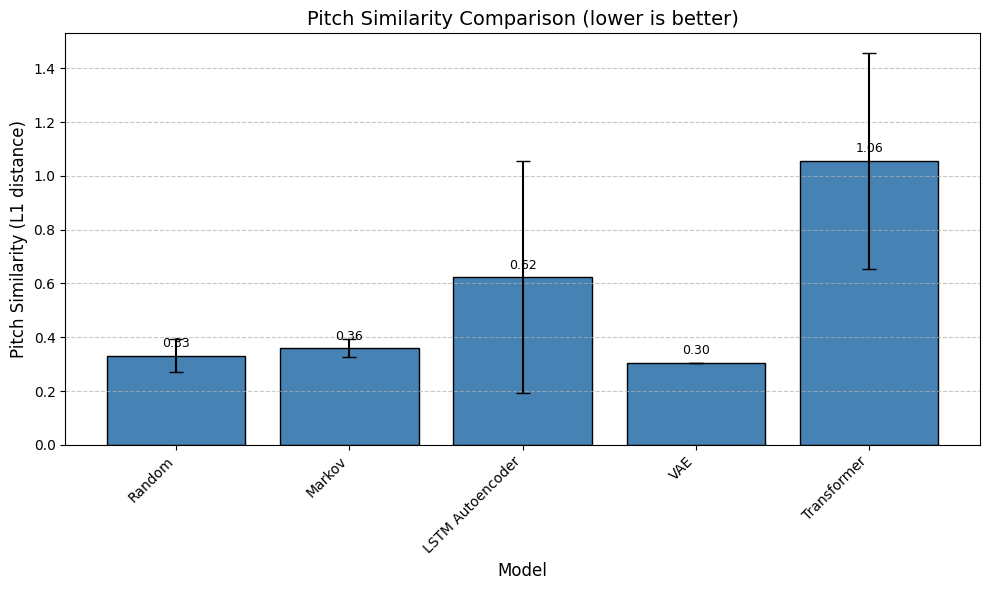

Saved: outputs/plots/pitch_similarity.png


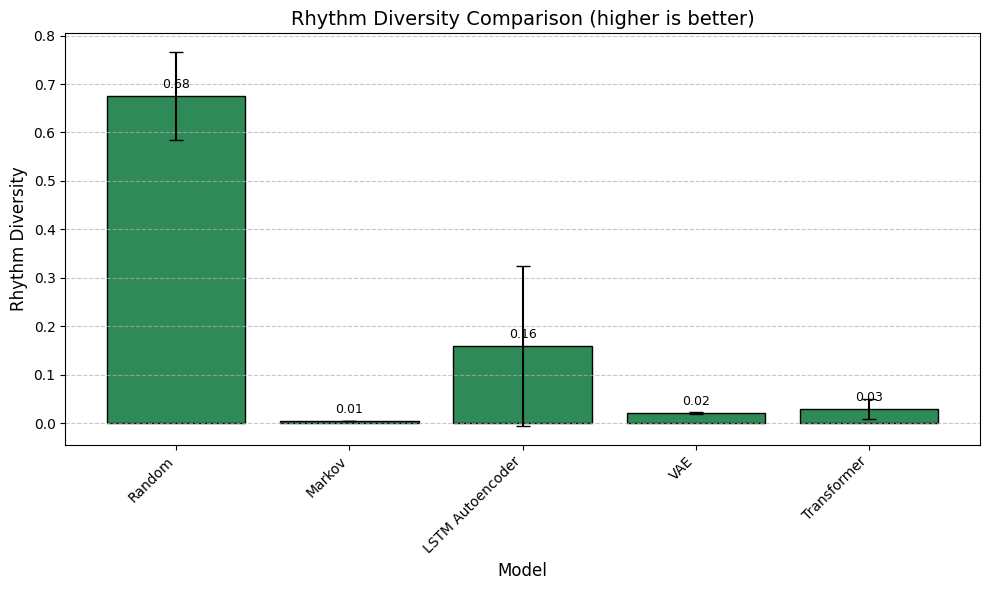

Saved: outputs/plots/rhythm_diversity.png


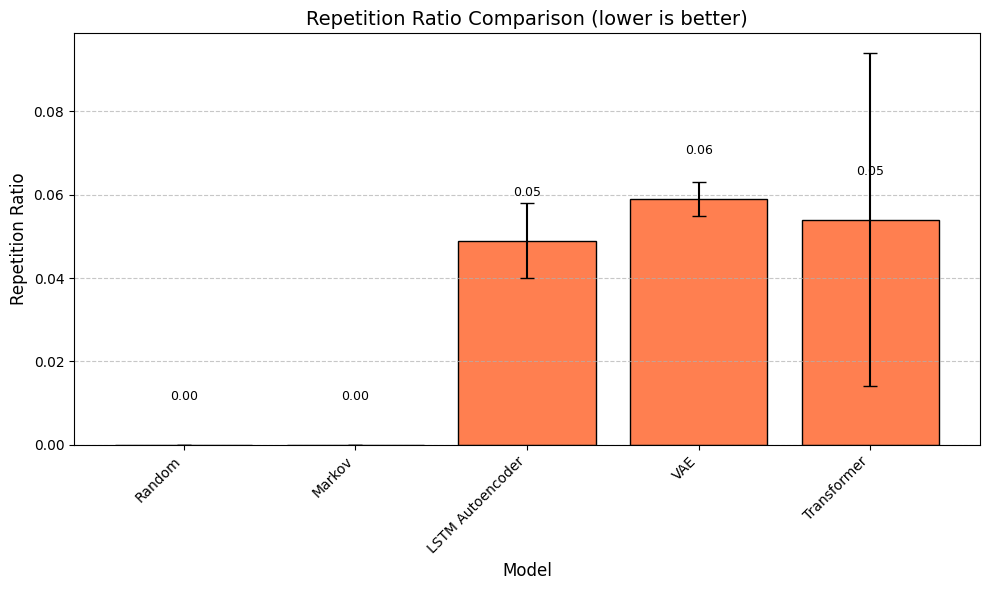

Saved: outputs/plots/repetition_ratio.png


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load metrics
df = pd.read_csv("outputs/final_results.csv")

# Helper to parse "mean ± std" strings
def parse_metric(value_str):
    try:
        mean, std = value_str.split(' ± ')
        return float(mean), float(std)
    except:
        return 0.0, 0.0

# Apply parsing to each metric column
df[['Pitch_Mean', 'Pitch_Std']] = df['Pitch Similarity ↓'].apply(lambda x: pd.Series(parse_metric(x)))
df[['Rhythm_Mean', 'Rhythm_Std']] = df['Rhythm Diversity ↑'].apply(lambda x: pd.Series(parse_metric(x)))
df[['Rep_Mean', 'Rep_Std']] = df['Repetition Ratio ↓'].apply(lambda x: pd.Series(parse_metric(x)))

models = df['Model'].tolist()
x = np.arange(len(models))
width = 0.7  # bar width

# ---- Figure 1: Pitch Similarity (lower better) ----
plt.figure(figsize=(10, 6))
bars = plt.bar(models, df['Pitch_Mean'], yerr=df['Pitch_Std'], capsize=5, color='steelblue', edgecolor='black')
plt.ylabel('Pitch Similarity (L1 distance)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.title('Pitch Similarity Comparison (lower is better)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/plots/pitch_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/plots/pitch_similarity.png")

# ---- Figure 2: Rhythm Diversity (higher better) ----
plt.figure(figsize=(10, 6))
bars = plt.bar(models, df['Rhythm_Mean'], yerr=df['Rhythm_Std'], capsize=5, color='seagreen', edgecolor='black')
plt.ylabel('Rhythm Diversity', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.title('Rhythm Diversity Comparison (higher is better)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/plots/rhythm_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/plots/rhythm_diversity.png")

# ---- Figure 3: Repetition Ratio (lower better) ----
plt.figure(figsize=(10, 6))
bars = plt.bar(models, df['Rep_Mean'], yerr=df['Rep_Std'], capsize=5, color='coral', edgecolor='black')
plt.ylabel('Repetition Ratio', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.title('Repetition Ratio Comparison (lower is better)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/plots/repetition_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/plots/repetition_ratio.png")

Loaded perplexity data:
   Epoch    Train_PPL      Val_PPL
0      1  3103.022723  2882.452471
1      2  2288.744313  1978.616649
2      3  1246.126943  1150.516633
3      4   894.080460   917.144667
4      5   706.556405   754.815422


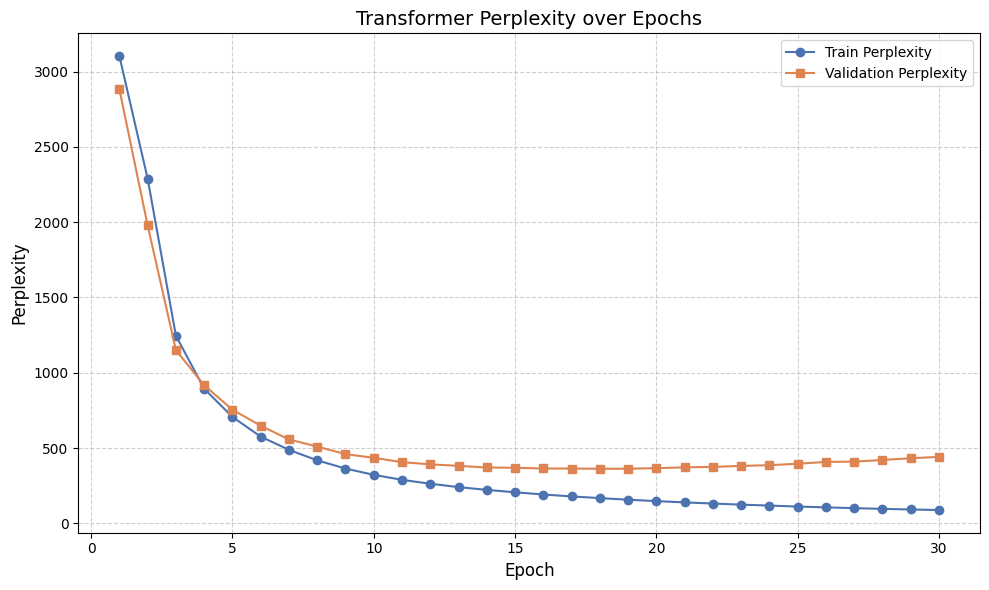

Saved: outputs/plots/transformer_perplexity_curve.png


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to saved perplexity CSV
csv_path = "outputs/transformer_perplexity.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("Loaded perplexity data:")
    print(df.head())
    
    plt.figure(figsize=(10, 6))
    plt.plot(df['Epoch'], df['Train_PPL'], marker='o', label='Train Perplexity', color='#4C72B0')
    plt.plot(df['Epoch'], df['Val_PPL'], marker='s', label='Validation Perplexity', color='#DD8452')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Perplexity', fontsize=12)
    plt.title('Transformer Perplexity over Epochs', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('outputs/plots/transformer_perplexity_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: outputs/plots/transformer_perplexity_curve.png")
else:
    print("Perplexity CSV not found. Run Transformer training first.")